# Отчёт по предобработке и разведочному анализу данных (EDA)

## 1. Загрузка и первичный осмотр данных

Источник данных: датасет с Kaggle Loan_default.csv (`https://www.kaggle.com/datasets/nikhil1e9/loan-default?resource=download`)
Исходный датасет содержит 255 347 записей, 18 столбцов.
Целевая переменная: `Default` (1 – дефолт, 0 – отсутствие дефолта).

Пропуски: отсутствуют (все столбцы имеют полное количество ненулевых значений).

Типы данных: 8 числовых (int64), 2 вещественных (float64), 8 категориальных (object).

## 2. Предобработка

Удалён неинформативный идентификатор LoanID.

Выполнено one-hot кодирование всех категориальных признаков: (Education, EmploymentType, MaritalStatus, HasMortgage, HasDependents, LoanPurpose, HasCoSigner).

Обработанный датасет содержит 32 числовых признака.

Сохранение обработанных данных: `/data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv`

## 3. Исследование дисбаланса классов

Доля дефолтных кредитов (Default = 1) составляет ≈ 11.6%.
Это `сильный` дисбаланс (почти 1:9), что потребует применения специальных техник при обучении моделей (взвешивание классов, SMOTE, корректировка порога классификации и т.д.).
Сильный дисбаланс устанавлевает целевой метрикой `Fscore` вместо классической `Accuracy`

## 4. Визуализация распределений
Для каждого признака построены:

Гистограмма (распределение частот).

Ящик с усами (boxplot) (выявление выбросов и разброса).

Графики сохранены в папку `/artifacts/EDA/figures`.

## 5. Основные выводы по числовым признакам

`Age`	Почти равномерное распределение от 18 до 69 лет, без явных пиков; выбросы не критичны.<br>
`Income`	Примерно симметричное, широкий разброс от 15 000 до 150 000. Есть единичные выбросы снизу.<br>
`LoanAmount`	Широкий диапазон (5 000 – 250 000), распределение близко к нормальному.<br>
`CreditScore`	Почти нормальное, но с лёгкой левой асимметрией; значения от 300 до 849.<br>
`MonthsEmployed`	Почти равномерное от 0 до 119, без резких пиков.<br>
`NumCreditLines`	Малые целые значения (1–4), большинство заёмщиков имеют 2–3 линии.<br>
`InterestRate`	Распределение близко к равномерному (2–25%), без явных аномалий.<br>
`LoanTerm`	Основные значения 24, 36, 48, 60 месяцев (кластеры).<br>
`DTIRatio`	Равномерное распределение (0.1–0.9), без экстремальных выбросов.<br>


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/RAW/Loan_default.csv")

In [121]:
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [111]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [112]:
df["Default"].value_counts(normalize=True)

Default
0    0.883872
1    0.116128
Name: proportion, dtype: float64

In [113]:
if "LoanID" in df.columns:
    df = df.drop("LoanID", axis=1)
df = pd.get_dummies(df, columns=df.select_dtypes(include='object').columns)
df[df.select_dtypes(include='bool').columns] = df.select_dtypes(include='bool').astype(np.int64)
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,HasMortgage_Yes,HasDependents_No,HasDependents_Yes,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_No,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,1,0,1,0,0,0,0,1,0,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,1,0,0,0,0,0,1,0,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,1,0,1,1,0,0,0,0,1,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,1,0,0,1,0,0,0,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,0,0,1,1,0,0,0,0,1,0


In [114]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,HasMortgage_Yes,HasDependents_No,HasDependents_Yes,LoanPurpose_Auto,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_No,HasCoSigner_Yes
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,...,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128,...,0.500014,0.499732,0.500268,0.199117,0.200895,0.199748,0.200848,0.199391,0.499892,0.500108
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379,...,0.500001,0.500001,0.500001,0.399337,0.400671,0.399812,0.400636,0.399544,0.500001,0.500001
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 32 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   Default                       255347 non-null  int64  
 10  Education_Bachelor's          255347 non-null  int64  
 11  Education_High School         255347 non-null  int64  
 12  Education_Master's            255347 non-nul

C:\Users\user\AppData\Local\Temp\ipykernel_21756\2903599870.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12, 6))


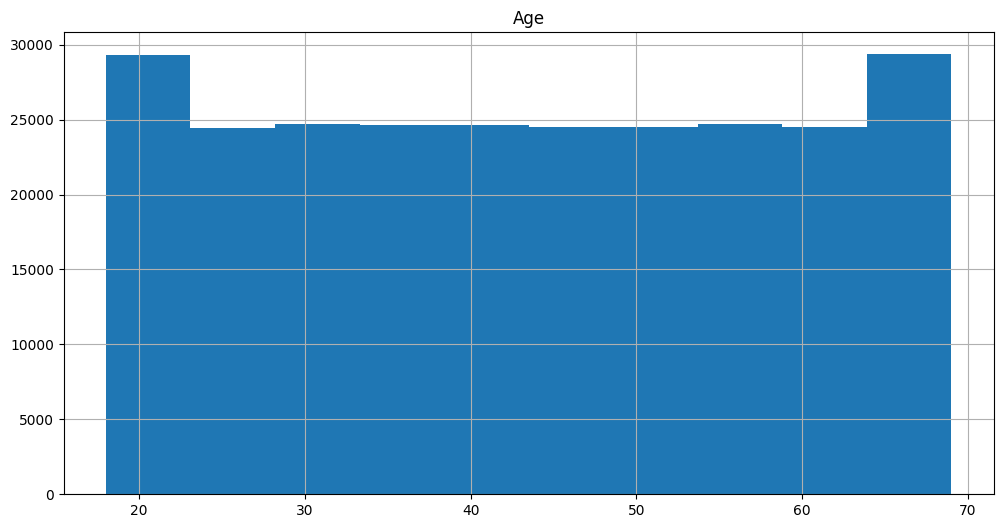

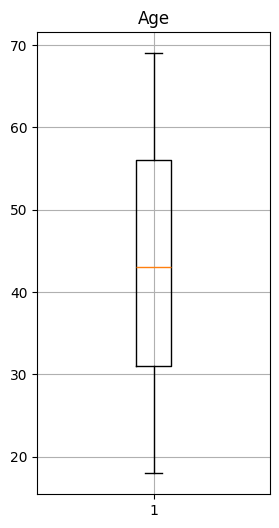

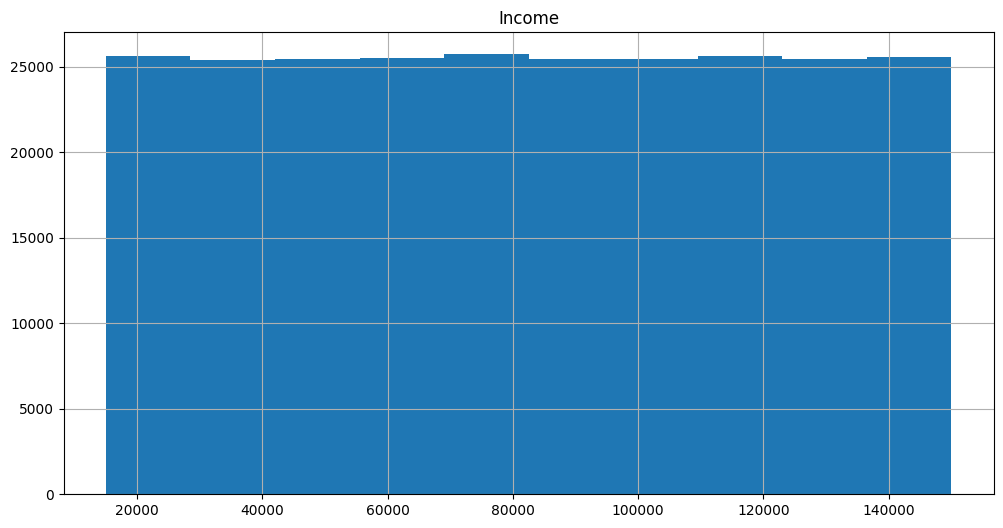

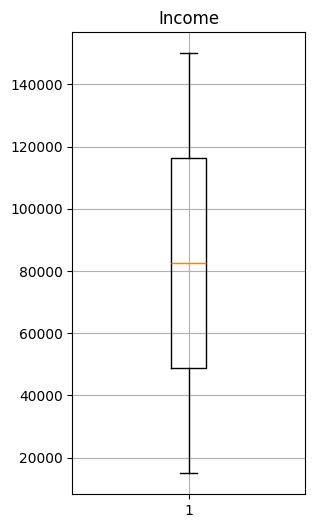

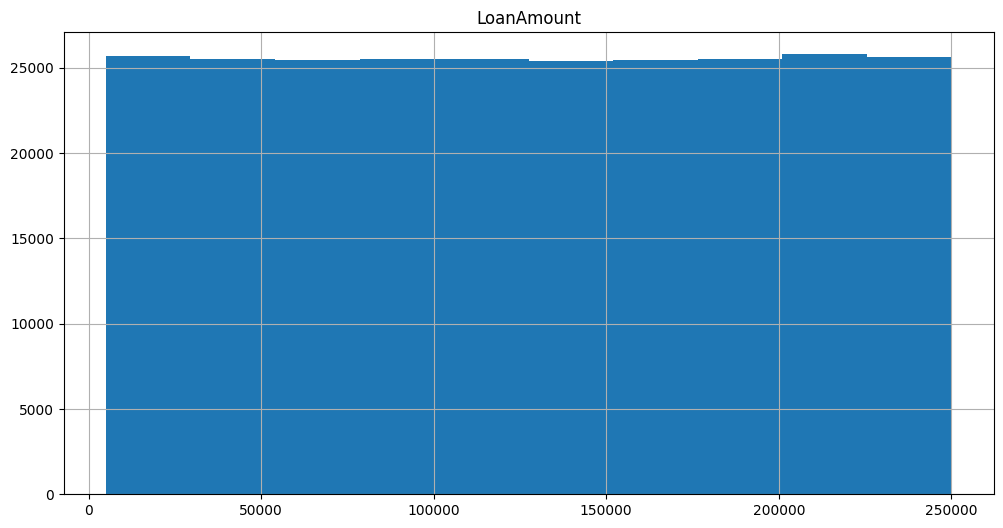

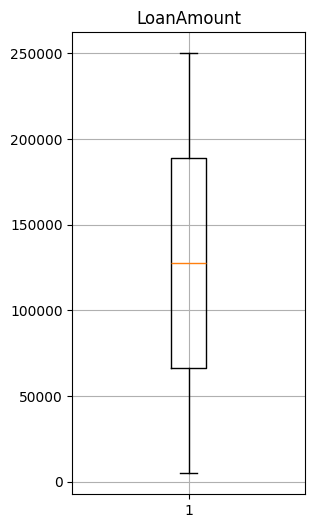

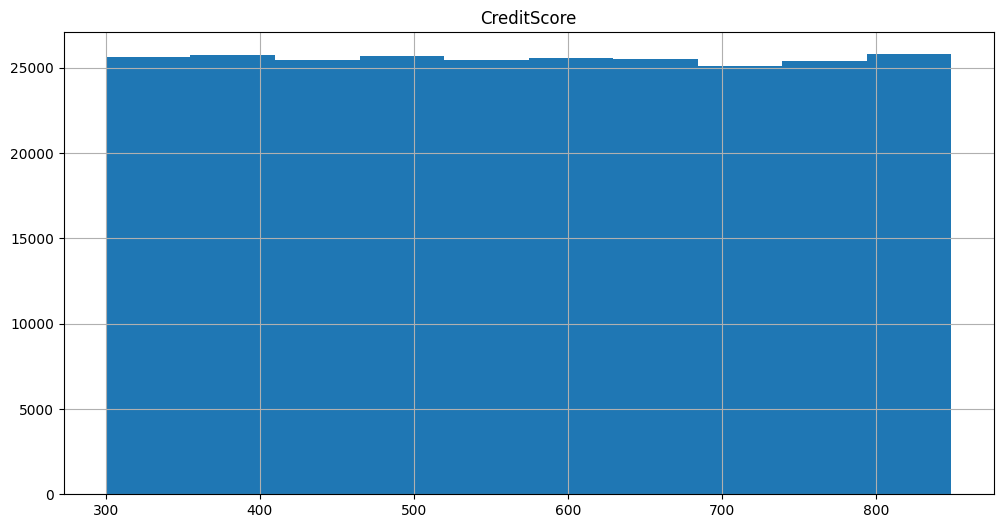

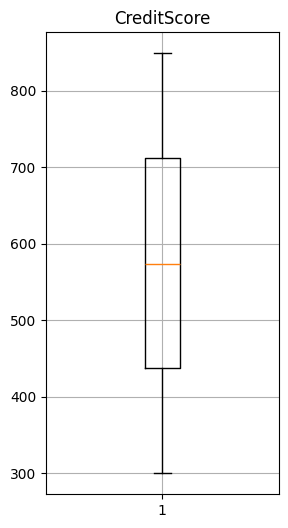

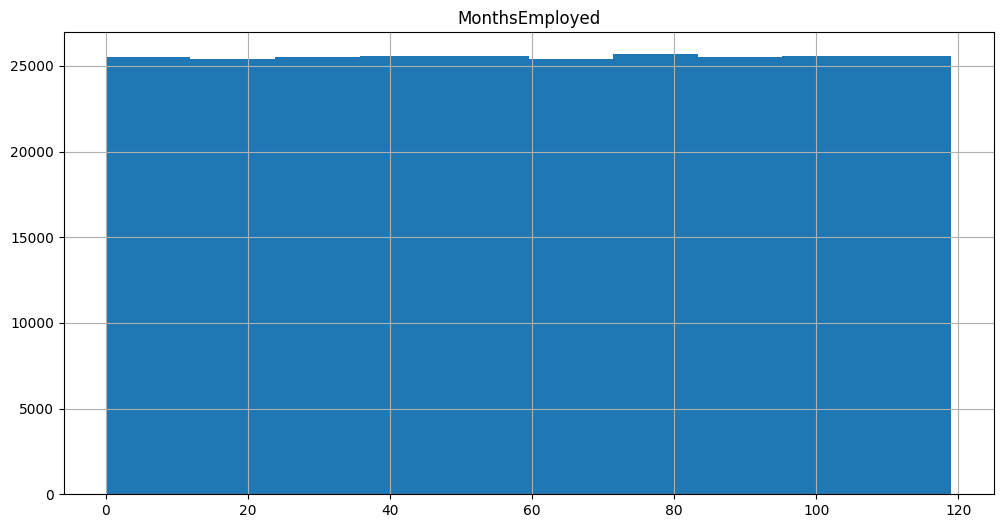

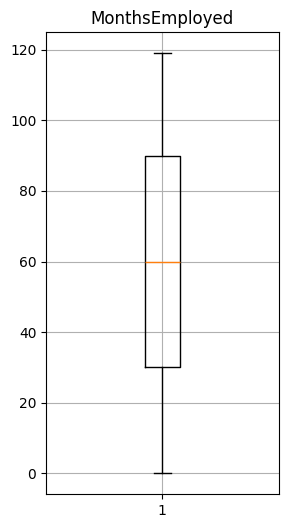

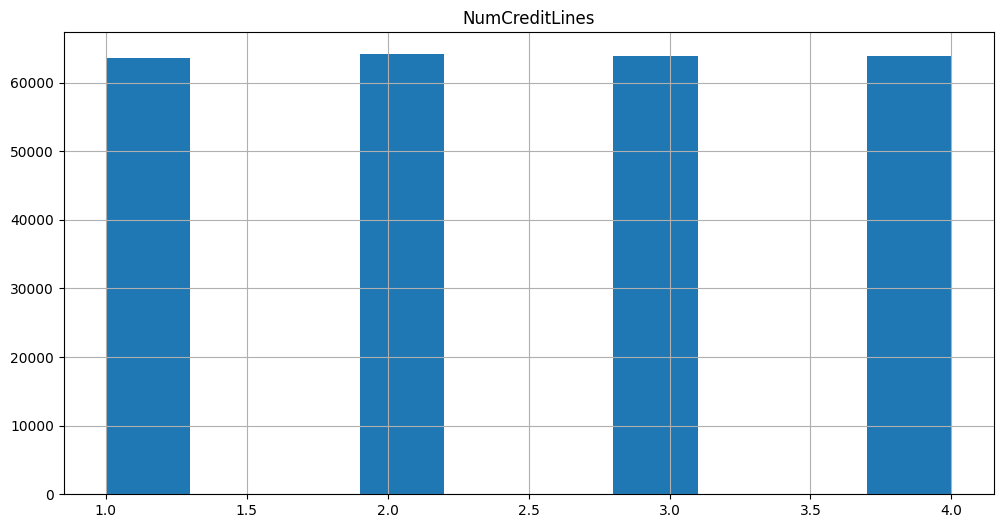

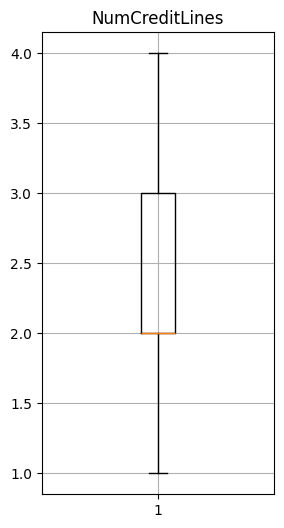

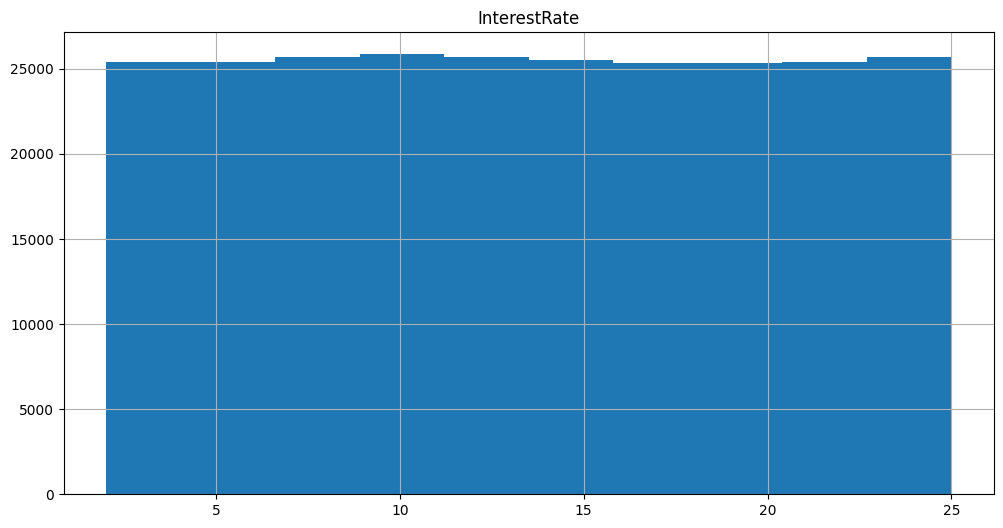

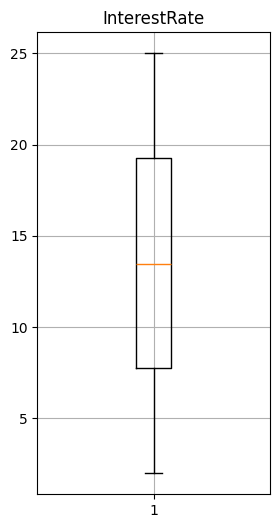

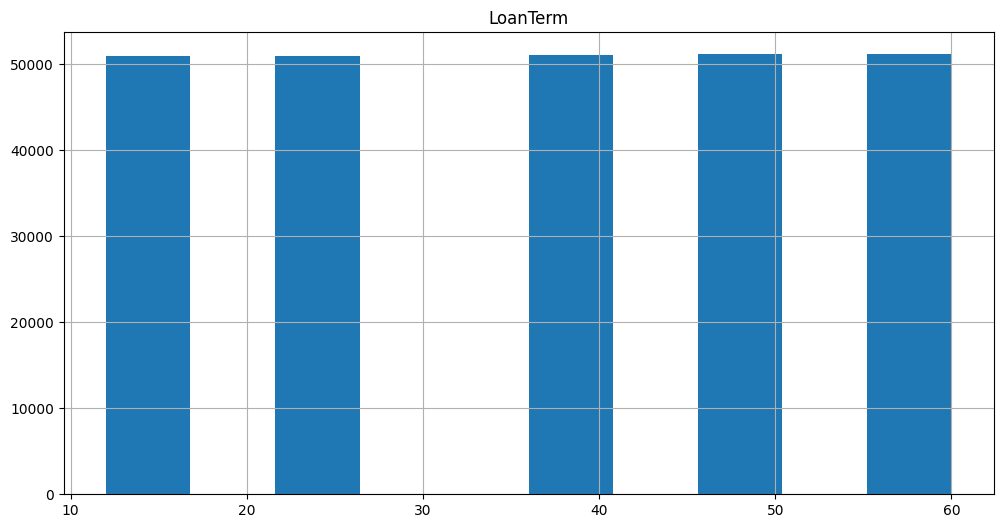

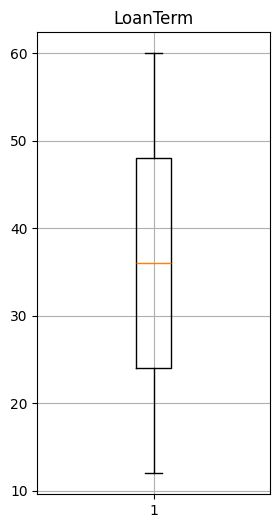

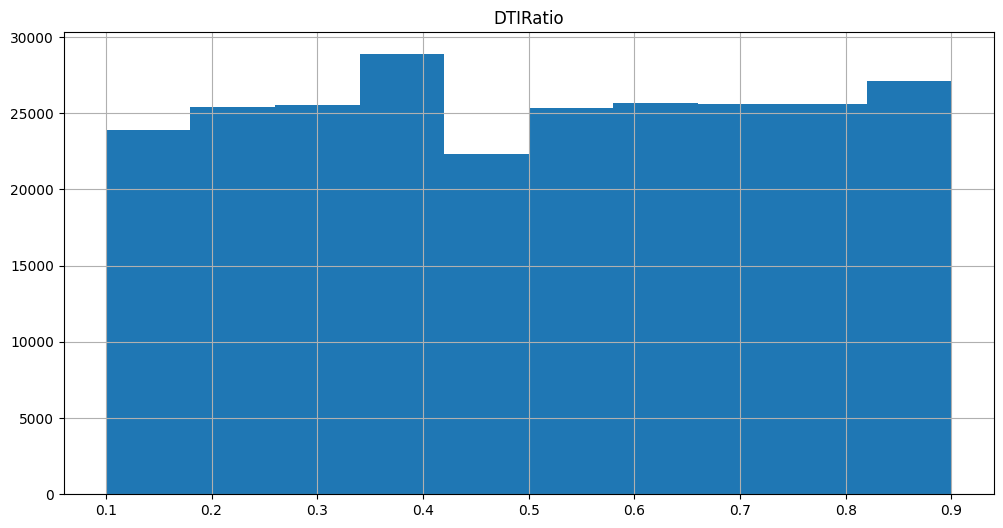

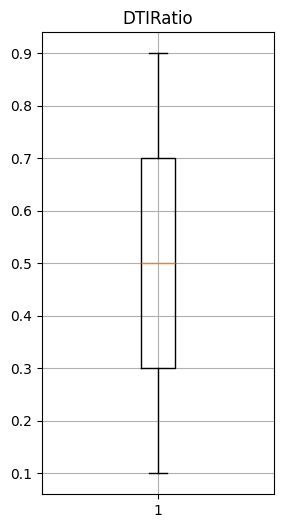

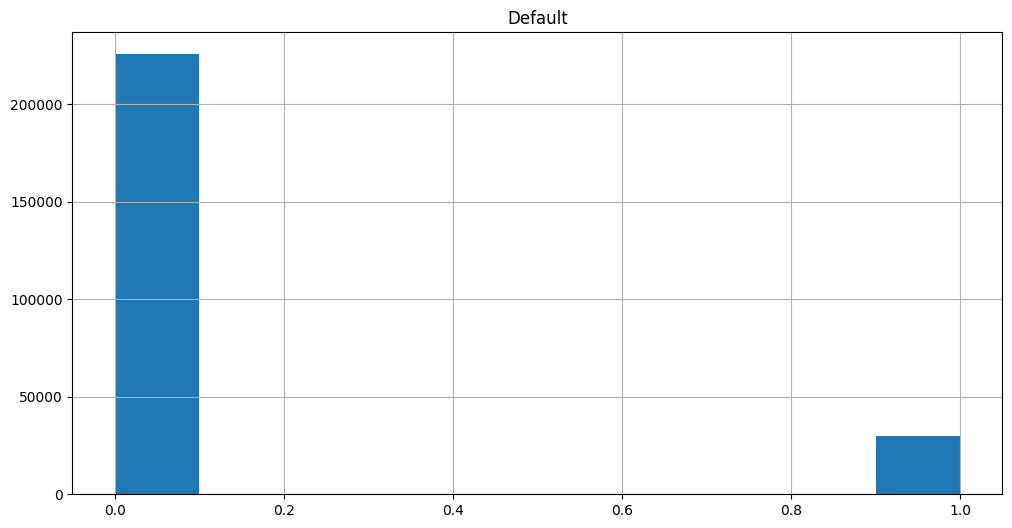

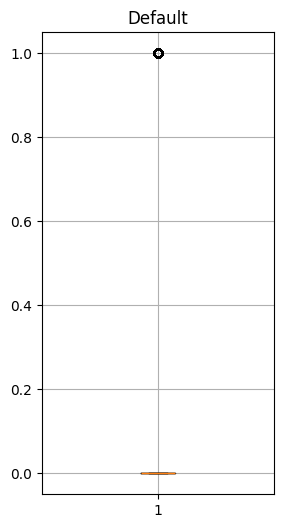

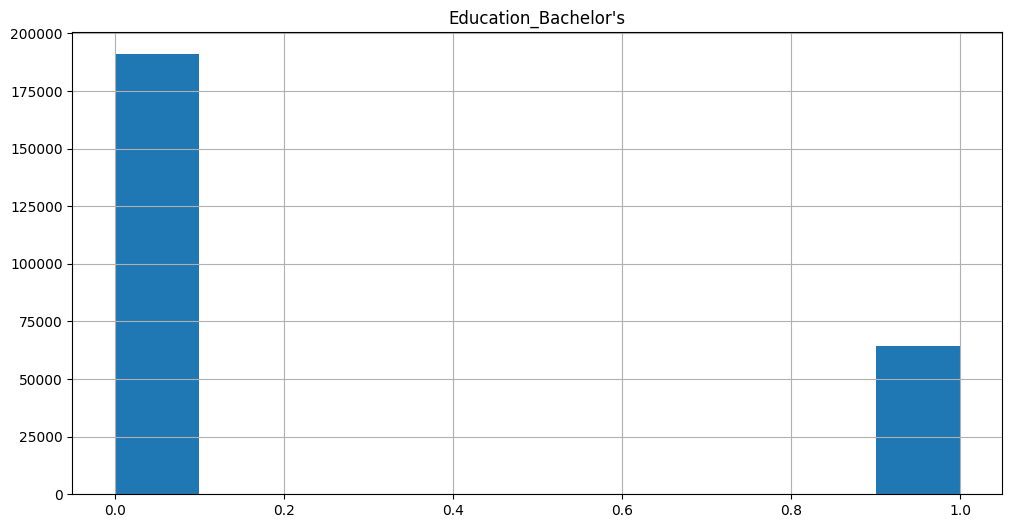

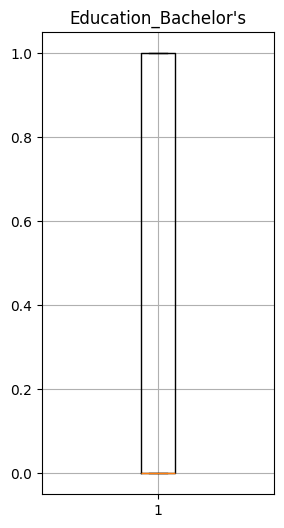

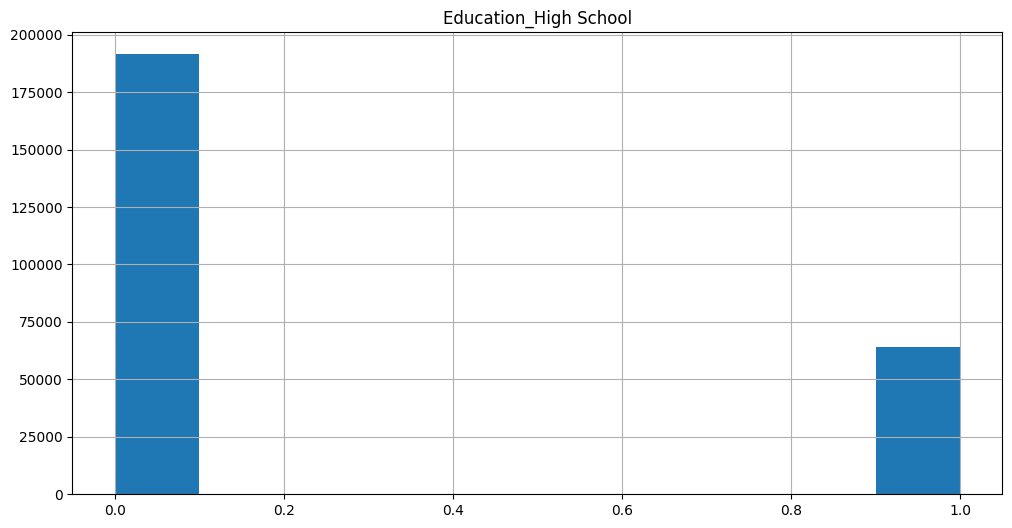

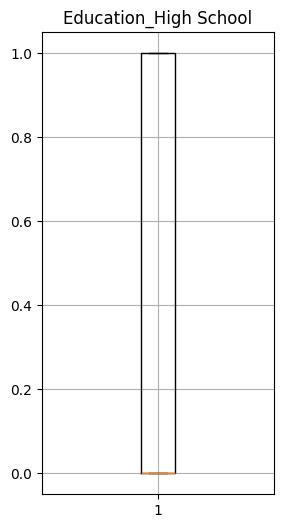

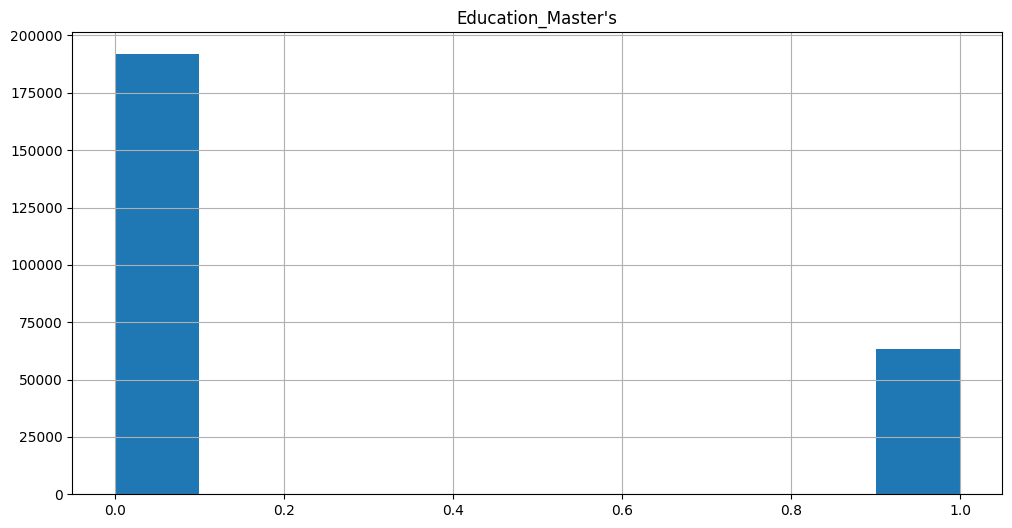

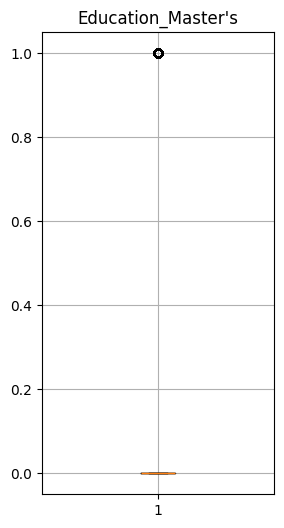

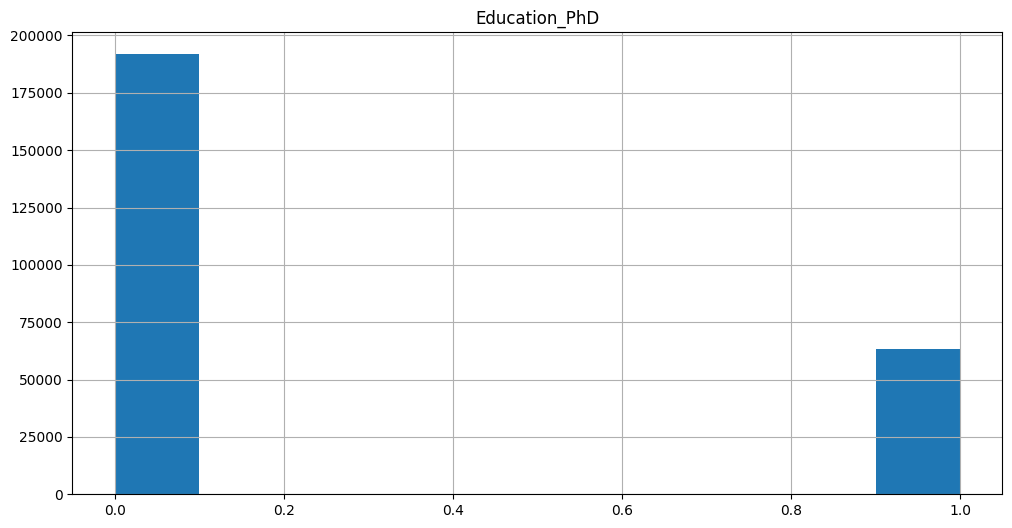

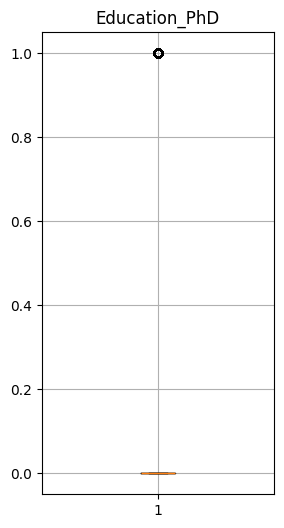

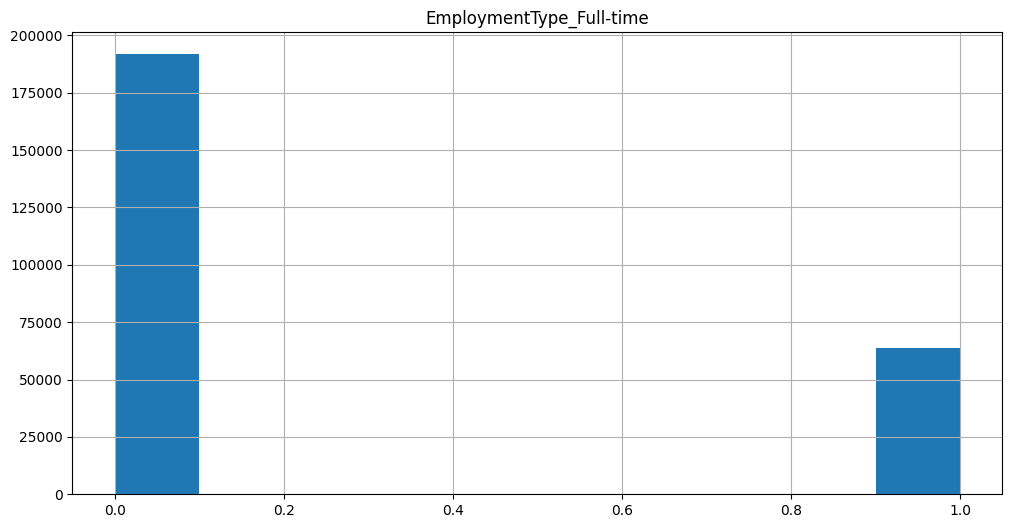

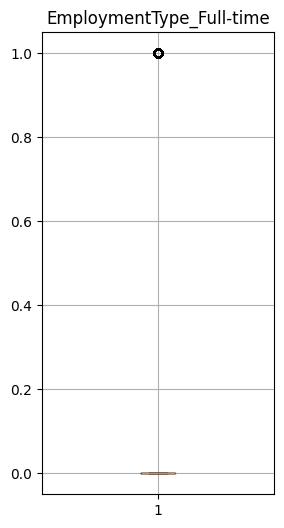

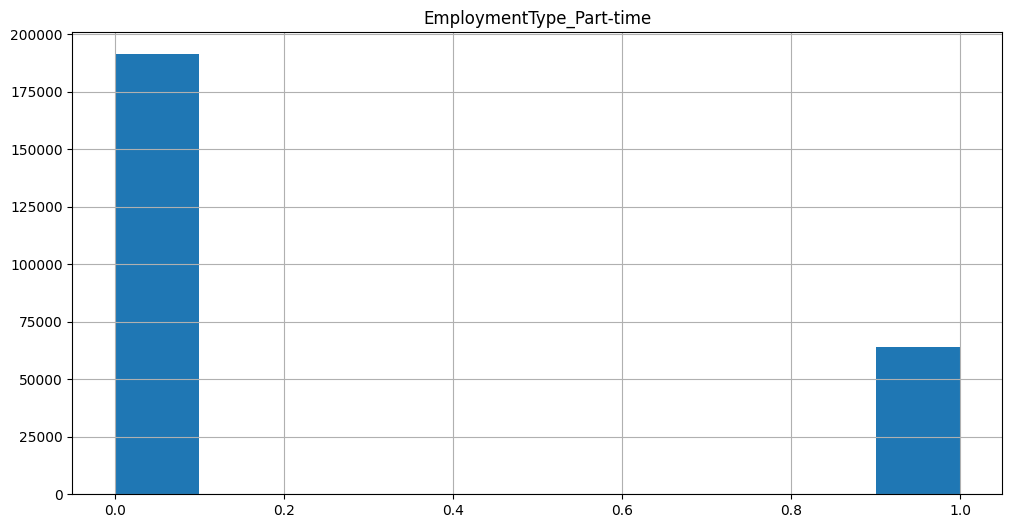

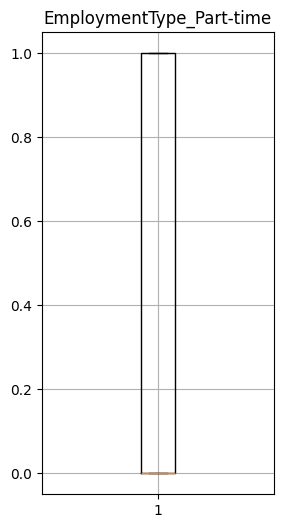

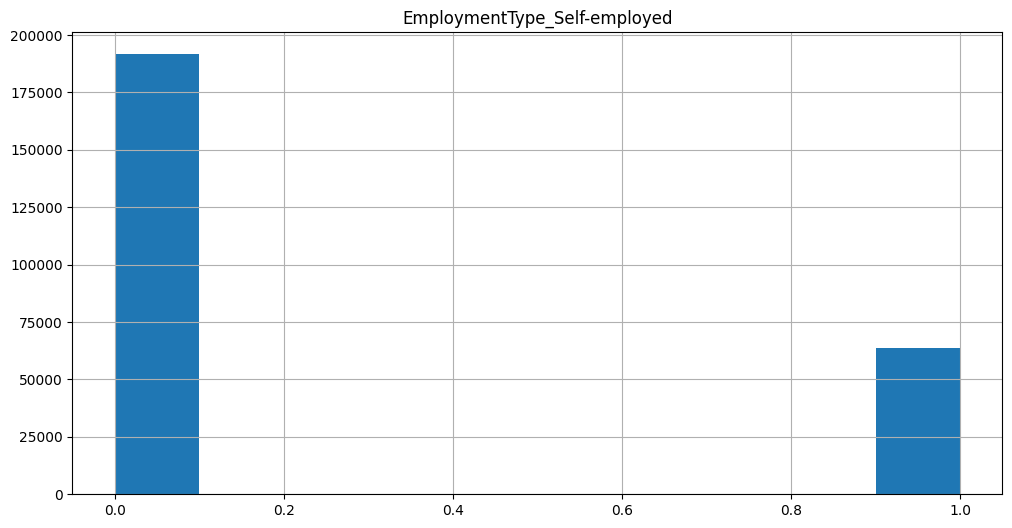

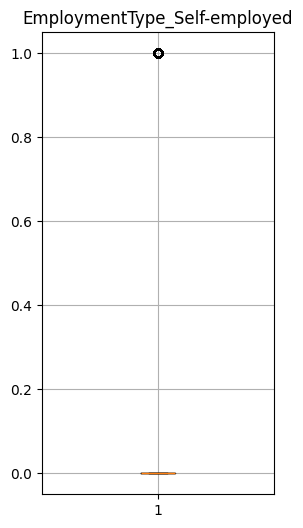

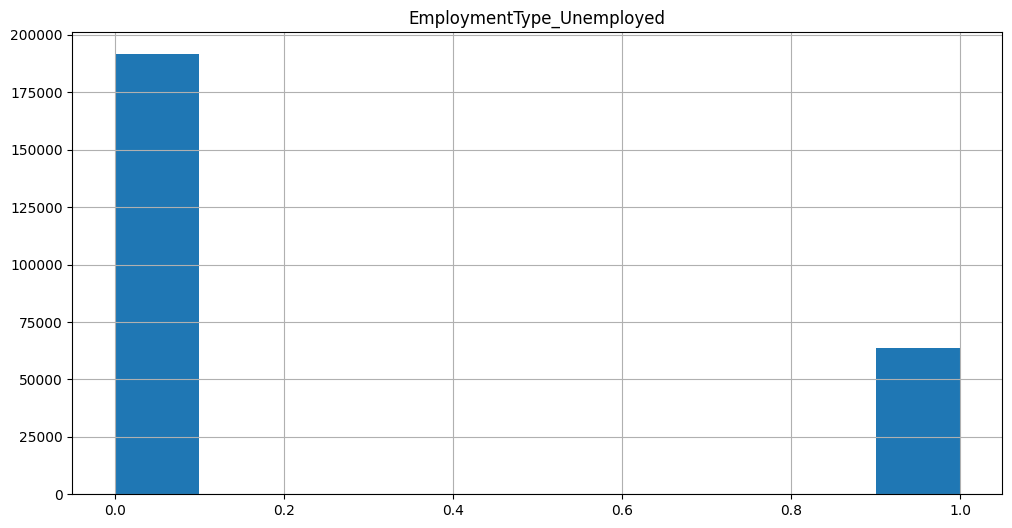

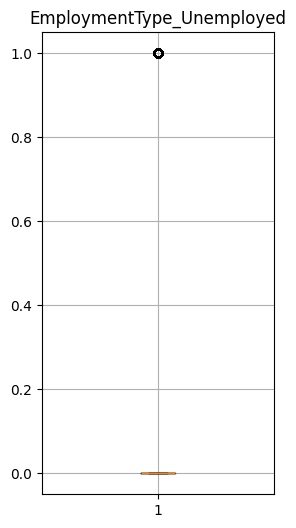

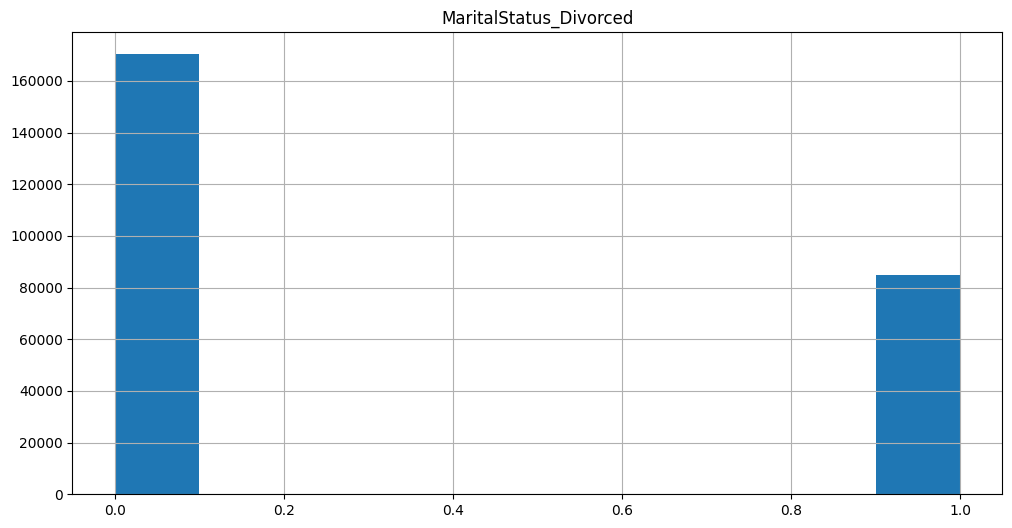

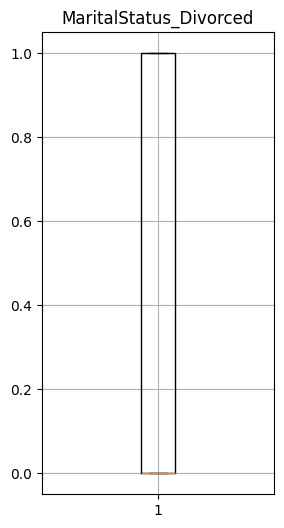

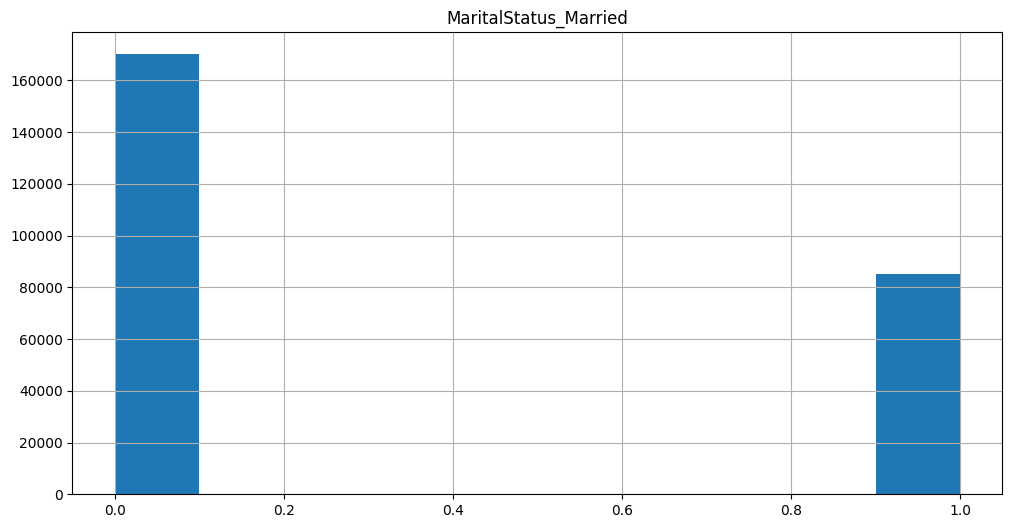

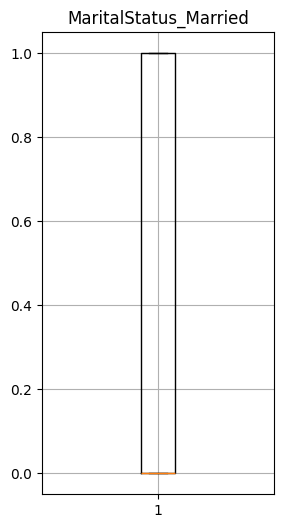

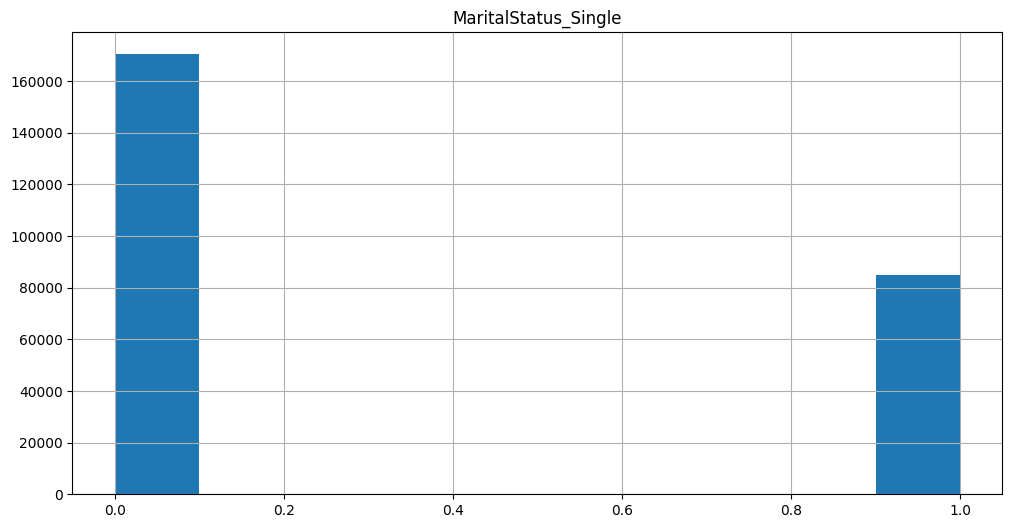

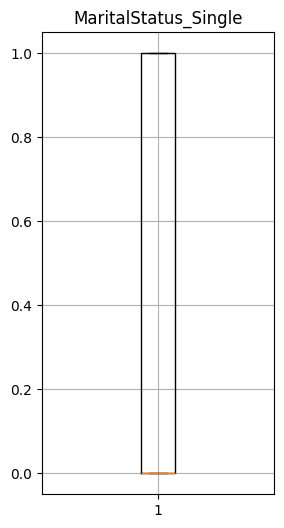

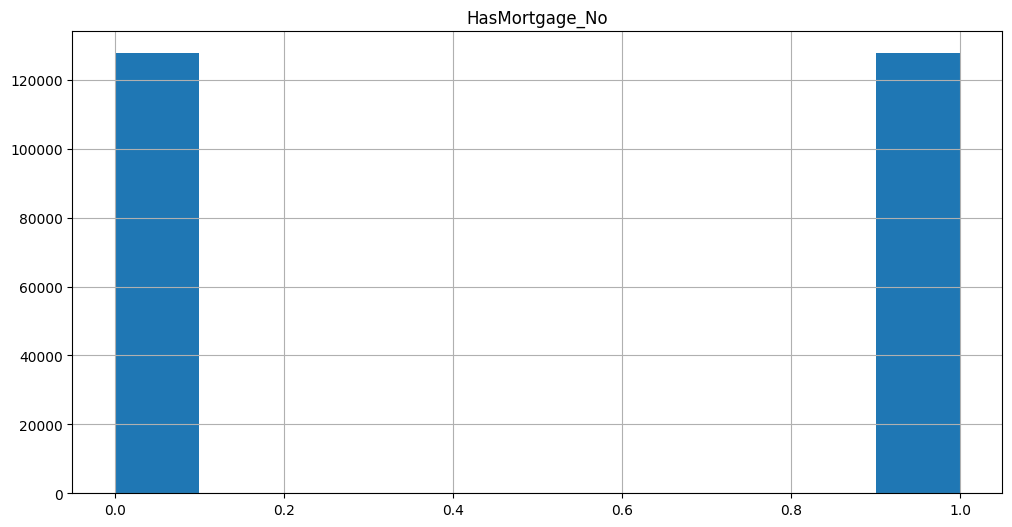

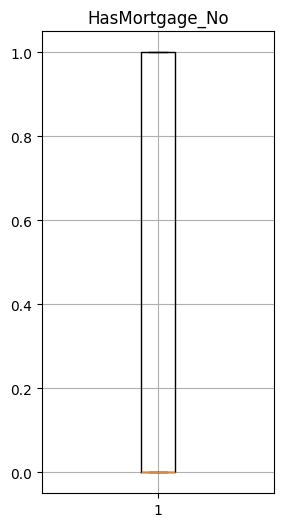

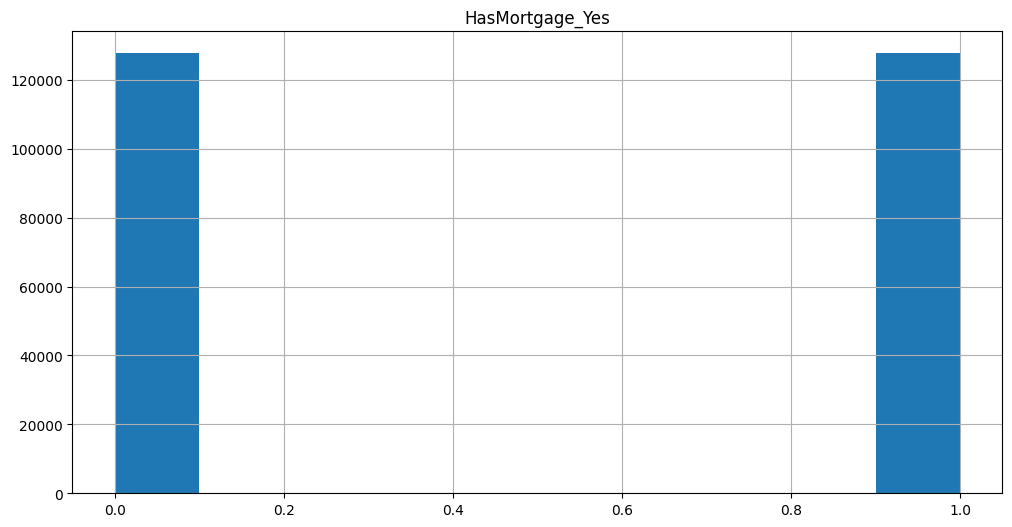

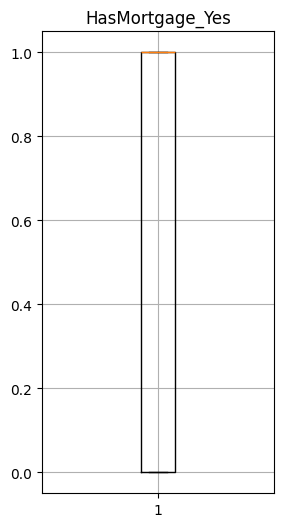

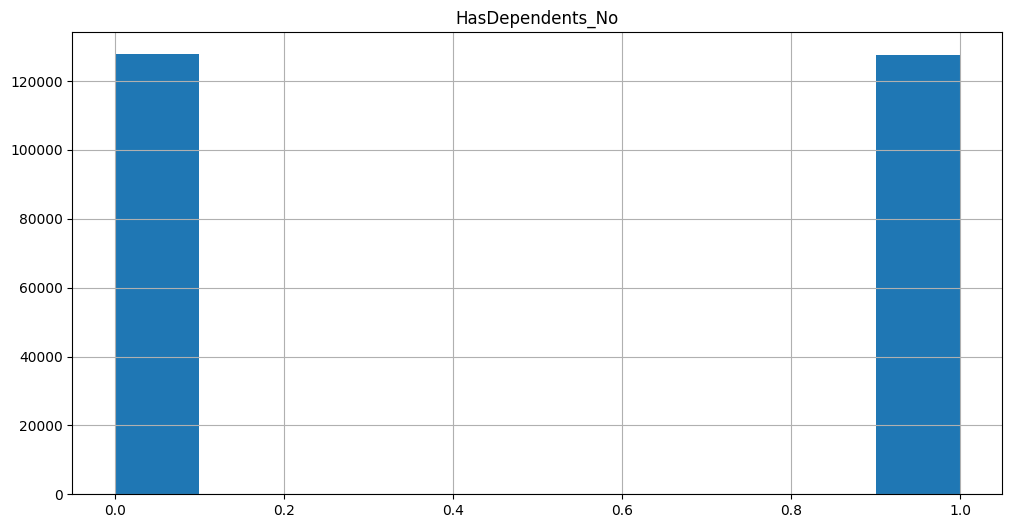

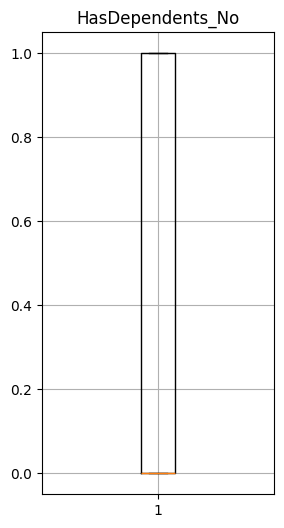

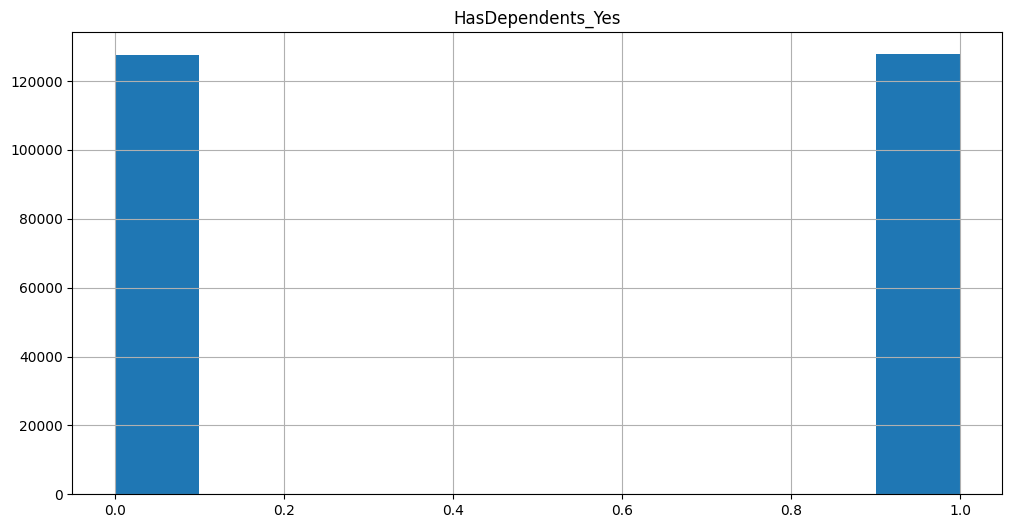

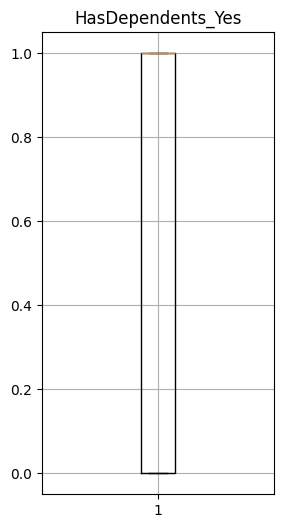

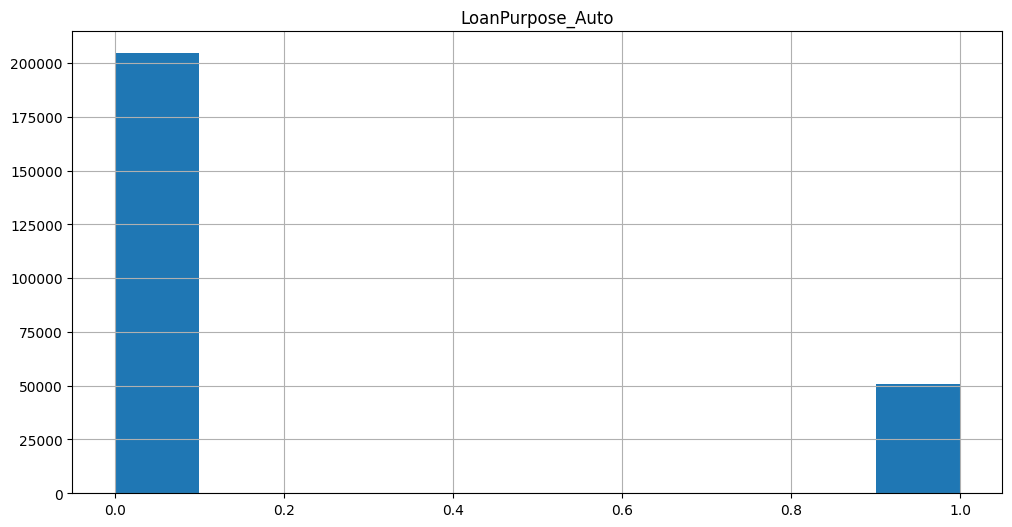

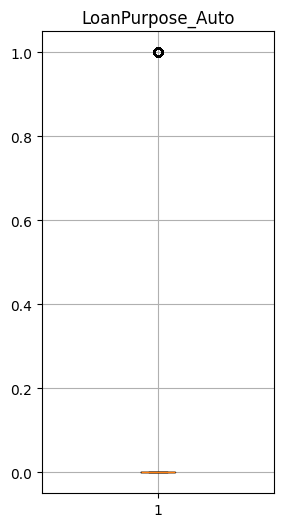

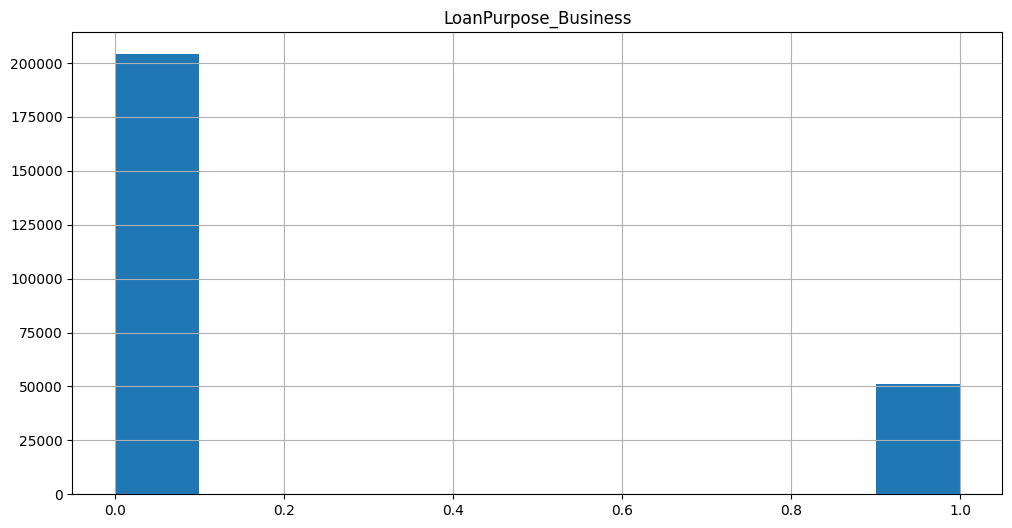

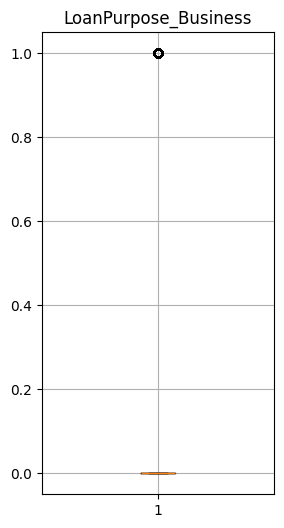

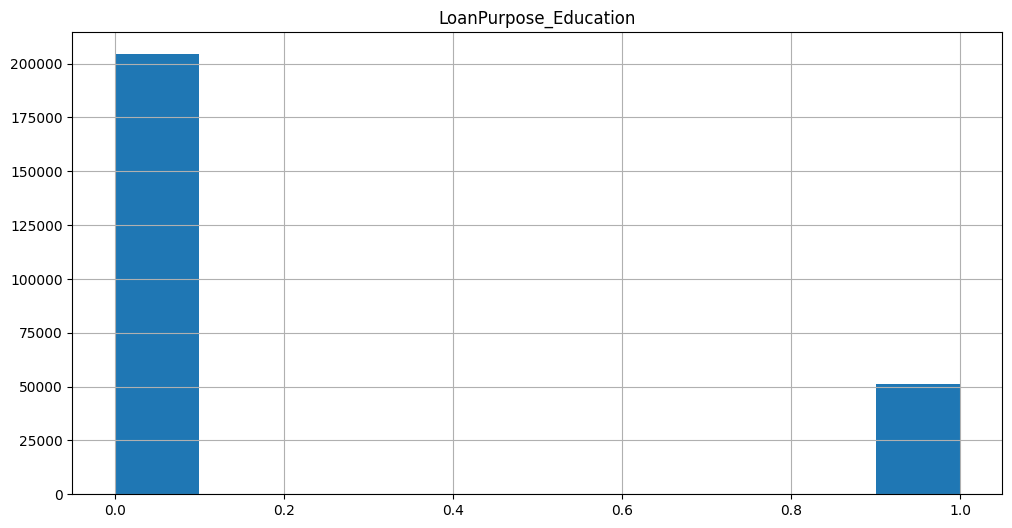

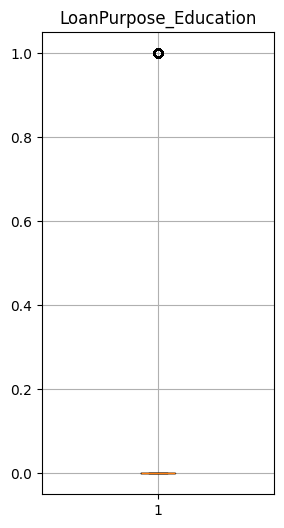

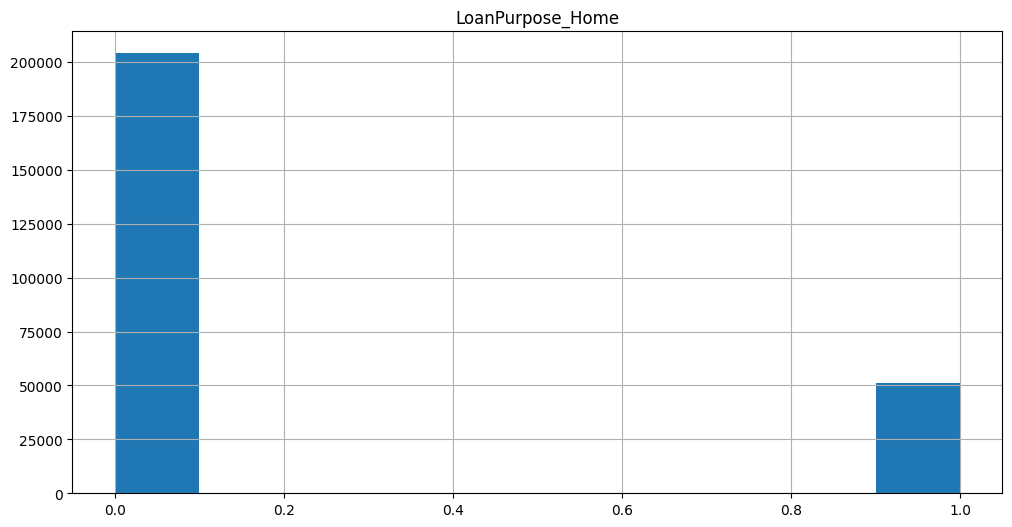

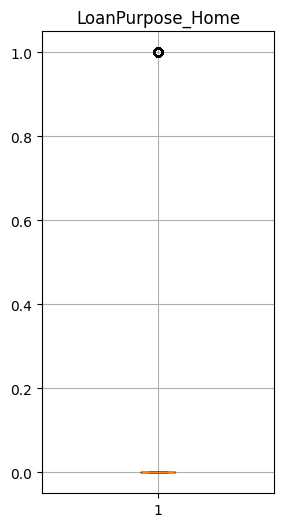

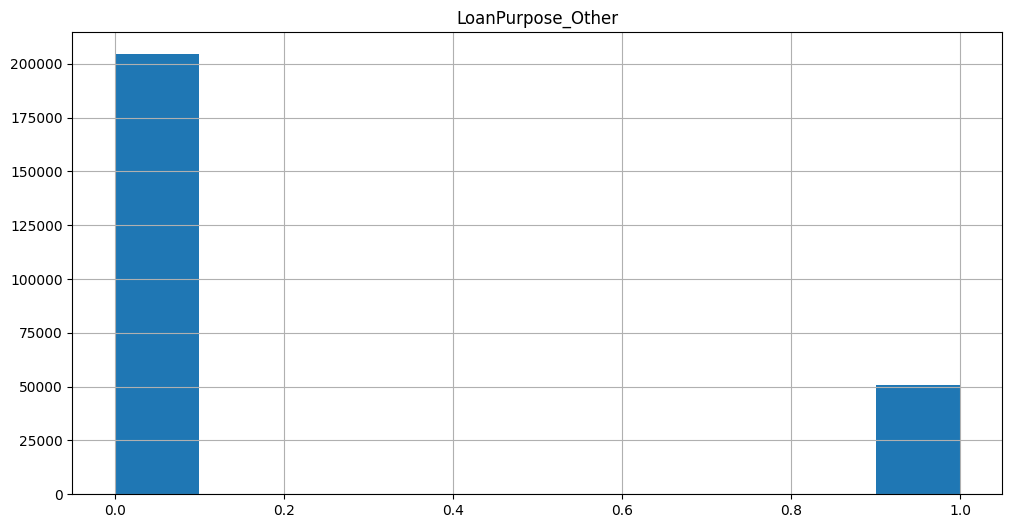

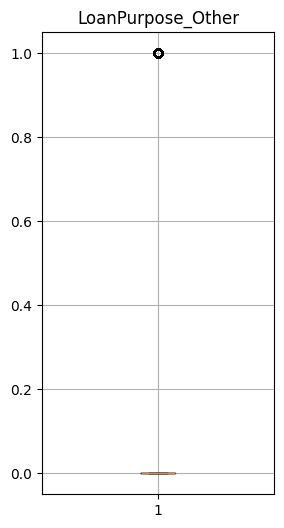

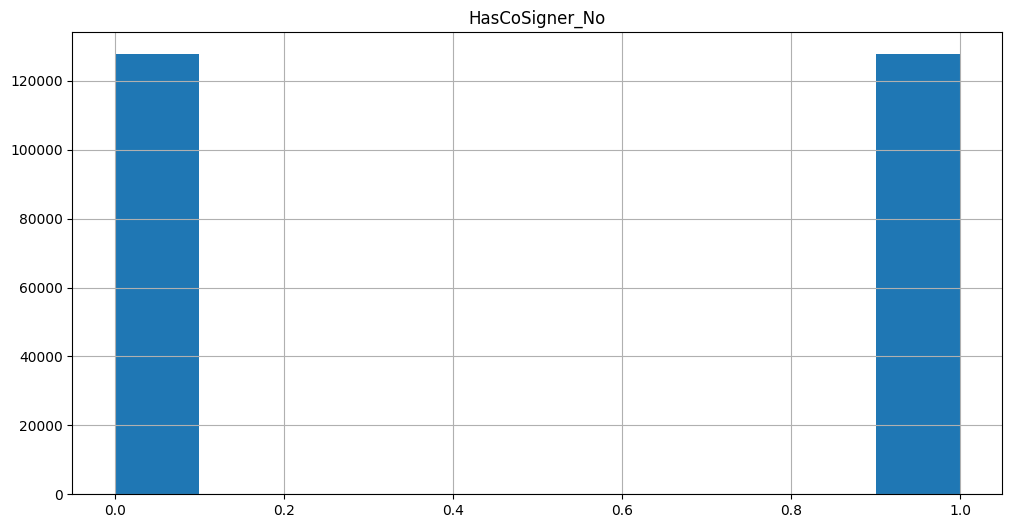

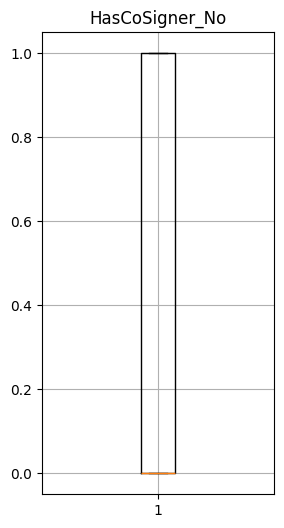

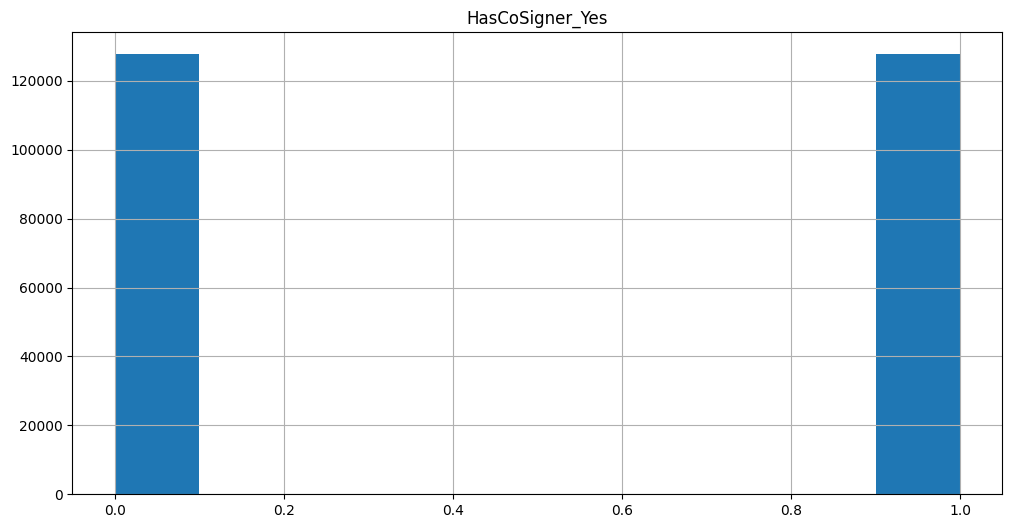

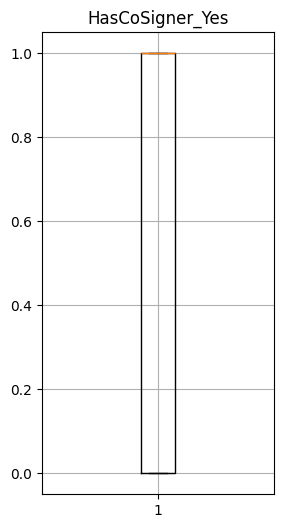

In [116]:
for i in df.columns:
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(df[i])
    ax.set_title(i)
    ax.grid(True)
    plt.savefig(f"../artifacts/EDA/figures/hist/hist_{i}.png")
    fig, ax = plt.subplots(figsize=(3, 6))
    ax.boxplot(df[i])
    ax.set_title(i)
    ax.grid(True)
    plt.savefig(f"../artifacts/EDA/figures/boxPlot/bp_{i}.png")

In [117]:
df.to_csv("../data/PROCESSED/LoanDefaultPredictionDatasetPROC.csv")